# Evolutionary Adversarial Reprogramming of Growing Neural Cellular Automata

This notebook contains code to reproduce experiments and figures regarding Growing CAs for the "Adversarial Reprogramming of Neural Cellular Automata" article.

Copyright 2020 Google LLC

Licensed under the Apache License, Version 2.0 (the "License");
you may not use this file except in compliance with the License.
You may obtain a copy of the License at

    https://www.apache.org/licenses/LICENSE-2.0

Unless required by applicable law or agreed to in writing, software
distributed under the License is distributed on an "AS IS" BASIS,
WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
See the License for the specific language governing permissions and
limitations under the License.

---
## Modifications
- Added SSIM, LPIPS, Fourier transform metrics.
- Added Phase 0: random baseline attack and metrics.
- Fourier metric can be computed on whole image or on 2x2 parts (toggle flag).
- Added Google Drive integration, model checkpointing, and CodeCarbon emissions tracking.

# Common code for both experiments

In [30]:
# Colab GPU check

import torch
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU found")

Tesla T4


In [31]:
# Use legacy keras - because code uses keras v2 and not v3

import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

In [32]:
#@title Setup Google Drive and Emissions Tracking
!pip install -q codecarbon
from google.colab import drive
import os

drive.mount('/content/drive')

PROJ_DIR = '/content/drive/MyDrive/MDSc_Radboud_University/NaturalComputing/NaCoProject/'
SAVE_DIR = f'{PROJ_DIR}experiments_1/'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f'Saving outputs to: {SAVE_DIR}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saving outputs to: /content/drive/MyDrive/MDSc_Radboud_University/NaturalComputing/NaCoProject/experiments_1/


In [33]:
#@title Imports and Notebook Utilities
%tensorflow_version 2.x

import io
import PIL.Image, PIL.ImageDraw
import base64
import zipfile
import json
import requests
import numpy as np
import matplotlib.pylab as pl
import glob
from codecarbon import EmissionsTracker, OutputMethod
import logging
logging.getLogger("codecarbon").setLevel(logging.ERROR)
import tensorflow as tf
from IPython.display import Image, HTML, clear_output
import tqdm

import os
os.environ['FFMPEG_BINARY'] = 'ffmpeg'
import moviepy.editor as mvp
from moviepy.video.io.ffmpeg_writer import FFMPEG_VideoWriter
clear_output()

def np2pil(a):
  if a.dtype in [np.float32, np.float64]:
    a = np.uint8(np.clip(a, 0, 1)*255)
  return PIL.Image.fromarray(a)

def imwrite(f, a, fmt=None):
  a = np.asarray(a)
  if isinstance(f, str):
    fmt = f.rsplit('.', 1)[-1].lower()
    if fmt == 'jpg':
      fmt = 'jpeg'
    f = open(f, 'wb')
  np2pil(a).save(f, fmt, quality=95)

def imencode(a, fmt='jpeg'):
  a = np.asarray(a)
  if len(a.shape) == 3 and a.shape[-1] == 4:
    fmt = 'png'
  f = io.BytesIO()
  imwrite(f, a, fmt)
  return f.getvalue()

def im2url(a, fmt='jpeg'):
  encoded = imencode(a, fmt)
  base64_byte_string = base64.b64encode(encoded).decode('ascii')
  return 'data:image/' + fmt.upper() + ';base64,' + base64_byte_string

def imshow(a, fmt='jpeg'):
  display(Image(data=imencode(a, fmt)))

def tile2d(a, w=None):
  a = np.asarray(a)
  if w is None:
    w = int(np.ceil(np.sqrt(len(a))))
  th, tw = a.shape[1:3]
  pad = (w-len(a))%w
  a = np.pad(a, [(0, pad)]+[(0, 0)]*(a.ndim-1), 'constant')
  h = len(a)//w
  a = a.reshape([h, w]+list(a.shape[1:]))
  a = np.rollaxis(a, 2, 1).reshape([th*h, tw*w]+list(a.shape[4:]))
  return a

def zoom(img, scale=4):
  img = np.repeat(img, scale, 0)
  img = np.repeat(img, scale, 1)
  return img

class VideoWriter:
  def __init__(self, filename, fps=30.0, **kw):
    self.writer = None
    self.params = dict(filename=filename, fps=fps, **kw)

  def add(self, img):
    img = np.asarray(img)
    if self.writer is None:
      h, w = img.shape[:2]
      self.writer = FFMPEG_VideoWriter(size=(w, h), **self.params)
    if img.dtype in [np.float32, np.float64]:
      img = np.uint8(img.clip(0, 1)*255)
    if len(img.shape) == 2:
      img = np.repeat(img[..., None], 3, -1)
    self.writer.write_frame(img)

  def close(self):
    if self.writer:
      self.writer.close()

  def __enter__(self):
    return self

  def __exit__(self, *kw):
    self.close()

In [34]:
#@title Cellular Automata Parameters
CHANNEL_N = 16        # Number of CA state channels
TARGET_SIZE = 40
BATCH_SIZE = 8
POOL_SIZE = 1024
CELL_FIRE_RATE = 0.5

EXPERIMENT_TYPE = "Regenerating" #@param ["Persistent", "Regenerating"]
EXPERIMENT_MAP = {"Persistent":0, "Regenerating":1}
EXPERIMENT_N = EXPERIMENT_MAP[EXPERIMENT_TYPE]
LOSS_THRESHOLD = -2.5

DAMAGE_N = [0, 3][EXPERIMENT_N]  # Number of patterns to damage in a batch

In [35]:
#@title CA Model and Utilities
#@markdown This model doesn't have a bias in the last layer.
from tensorflow.keras.layers import Conv2D

def load_image(url, max_size=TARGET_SIZE):
  r = requests.get(url)
  img = PIL.Image.open(io.BytesIO(r.content))
  img.thumbnail((max_size, max_size), PIL.Image.LANCZOS)
  img = np.float32(img)/255.0
  # premultiply RGB by Alpha
  img[..., :3] *= img[..., 3:]
  return img

def to_rgba(x):
  return x[..., :4]

def to_alpha(x):
  return tf.clip_by_value(x[..., 3:4], 0.0, 1.0)

def to_rgb(x):
  # assume rgb premultiplied by alpha
  rgb, a = x[..., :3], to_alpha(x)
  return 1.0-a+rgb

def get_living_mask(x):
  alpha = x[:, :, :, 3:4]
  return tf.nn.max_pool2d(alpha, 3, [1, 1, 1, 1], 'SAME') > 0.1

def make_seed(size, n=1):
  x = np.zeros([n, size, size, CHANNEL_N], np.float32)
  x[:, size//2, size//2, 3:] = 1.0
  return x


class CAModel(tf.keras.Model):

  def __init__(self, channel_n=CHANNEL_N, fire_rate=CELL_FIRE_RATE):
    super().__init__()
    self.channel_n = channel_n
    self.fire_rate = fire_rate

    self.dmodel = tf.keras.Sequential([
          Conv2D(128, 1, activation=tf.nn.relu),
          Conv2D(self.channel_n, 1, activation=None,
              kernel_initializer=tf.zeros_initializer),
    ])

    self(tf.zeros([1, 3, 3, channel_n]))  # dummy call to build the model

  @tf.function
  def perceive(self, x, angle=0.0):
    identify = np.float32([0, 1, 0])
    identify = np.outer(identify, identify)
    dx = np.outer([1, 2, 1], [-1, 0, 1]) / 8.0  # Sobel filter
    dy = dx.T
    c, s = tf.cos(angle), tf.sin(angle)
    kernel = tf.stack([identify, c*dx-s*dy, s*dx+c*dy], -1)[:, :, None, :]
    kernel = tf.repeat(kernel, self.channel_n, 2)
    y = tf.nn.depthwise_conv2d(x, kernel, [1, 1, 1, 1], 'SAME')
    return y

  @tf.function
  def call(self, x, fire_rate=None, angle=0.0, step_size=1.0):
    pre_life_mask = get_living_mask(x)

    y = self.perceive(x, angle)
    dx = self.dmodel(y)*step_size
    if fire_rate is None:
      fire_rate = self.fire_rate
    update_mask = tf.random.uniform(tf.shape(x[:, :, :, :1])) <= fire_rate
    x += dx * tf.cast(update_mask, tf.float32)

    post_life_mask = get_living_mask(x)
    life_mask = pre_life_mask & post_life_mask
    return x * tf.cast(life_mask, tf.float32)


CAModel().dmodel.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_8 (Conv2D)           (1, 3, 3, 128)            6272      
                                                                 
 conv2d_9 (Conv2D)           (1, 3, 3, 16)             2064      
                                                                 
Total params: 8336 (32.56 KB)
Trainable params: 8336 (32.56 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [36]:
#@title Train Utilities (SamplePool, Model Export, Damage)
from google.protobuf.json_format import MessageToDict
from tensorflow.python.framework import convert_to_constants

class SamplePool:
  def __init__(self, *, _parent=None, _parent_idx=None, **slots):
    self._parent = _parent
    self._parent_idx = _parent_idx
    self._slot_names = slots.keys()
    self._size = None
    for k, v in slots.items():
      if self._size is None:
        self._size = len(v)
      assert self._size == len(v)
      setattr(self, k, np.asarray(v))

  def sample(self, n):
    idx = np.random.choice(self._size, n, False)
    batch = {k: getattr(self, k)[idx] for k in self._slot_names}
    batch = SamplePool(**batch, _parent=self, _parent_idx=idx)
    return batch

  def commit(self):
    for k in self._slot_names:
      getattr(self._parent, k)[self._parent_idx] = getattr(self, k)

@tf.function
def make_circle_masks(n, h, w):
  x = tf.linspace(-1.0, 1.0, w)[None, None, :]
  y = tf.linspace(-1.0, 1.0, h)[None, :, None]
  center = tf.random.uniform([2, n, 1, 1], -0.5, 0.5)
  r = tf.random.uniform([n, 1, 1], 0.1, 0.4)
  x, y = (x-center[0])/r, (y-center[1])/r
  mask = tf.cast(x*x+y*y < 1.0, tf.float32)
  return mask

def export_model(ca, base_fn):
  ca.save_weights(base_fn)

  cf = ca.call.get_concrete_function(
      x=tf.TensorSpec([None, None, None, CHANNEL_N]),
      fire_rate=tf.constant(0.5),
      angle=tf.constant(0.0),
      step_size=tf.constant(1.0))
  cf = convert_to_constants.convert_variables_to_constants_v2(cf)
  graph_def = cf.graph.as_graph_def()
  graph_json = MessageToDict(graph_def)
  graph_json['versions'] = dict(producer='1.14', minConsumer='1.14')
  model_json = {
      'format': 'graph-model',
      'modelTopology': graph_json,
      'weightsManifest': [],
  }
  with open(base_fn+'.json', 'w') as f:
    json.dump(model_json, f)

def generate_pool_figures(pool, step_i):
  tiled_pool = tile2d(to_rgb(pool.x[:49]))
  fade = np.linspace(1.0, 0.0, 72)
  ones = np.ones(72)
  tiled_pool[:, :72] += (-tiled_pool[:, :72] + ones[None, :, None]) * fade[None, :, None]
  tiled_pool[:, -72:] += (-tiled_pool[:, -72:] + ones[None, :, None]) * fade[None, ::-1, None]
  tiled_pool[:72, :] += (-tiled_pool[:72, :] + ones[:, None, None]) * fade[:, None, None]
  tiled_pool[-72:, :] += (-tiled_pool[-72:, :] + ones[:, None, None]) * fade[::-1, None, None]
  imwrite('train_log/%04d_pool.jpg'%step_i, tiled_pool)

def visualize_batch(x0, x, step_i):
  vis0 = np.hstack(to_rgb(x0).numpy())
  vis1 = np.hstack(to_rgb(x).numpy())
  vis = np.vstack([vis0, vis1])
  imwrite('train_log/batches_%04d.jpg'%step_i, vis)
  print('batch (before/after):')
  imshow(vis)

def plot_loss(loss_log):
  pl.figure(figsize=(10, 4))
  pl.title('Loss history (log10)')
  pl.plot(np.log10(loss_log), '.', alpha=0.1)
  pl.show()


In [37]:
!wget -O models.zip 'https://github.com/google-research/self-organising-systems/blob/master/assets/growing_ca/models.zip?raw=true'
!unzip -oq models.zip

# available pretrained emoji are:
#EMOJI = '🦎😀💥👁🐠🦋🐞🕸🥨🎄'

def get_model(emoji='🦎', fire_rate=0.5, use_pool=1, damage_n=3, run=0,
              prefix='models/', output='model'):
  path = prefix
  assert fire_rate in [0.5, 1.0]
  if fire_rate==0.5:
    path += 'use_sample_pool_%d damage_n_%d '%(use_pool, damage_n)
  elif fire_rate==1.0:
    path += 'fire_rate_1.0 '
  code = hex(ord(emoji))[2:].upper()
  path += 'target_emoji_%s run_index_%d/08000'%(code, run)
  assert output in ['model', 'json']
  if output == 'model':
    ca = CAModel(channel_n=16, fire_rate=fire_rate)
    ca.load_weights(path)
    return ca
  elif output == 'json':
    return open(path+'.json', 'r').read()

def get_local_model(path, output='model'):
  assert output in ['model', 'json']
  if output == 'model':
    ca = CAModel(channel_n=16)
    ca.load_weights(path)
    return ca
  elif output == 'json':
    return open(path+'.json', 'r').read()


--2026-06-12 10:43:22--  https://github.com/google-research/self-organising-systems/blob/master/assets/growing_ca/models.zip?raw=true
Resolving github.com (github.com)... 140.82.113.3
Connecting to github.com (github.com)|140.82.113.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/google-research/self-organising-systems/raw/refs/heads/master/assets/growing_ca/models.zip [following]
--2026-06-12 10:43:23--  https://github.com/google-research/self-organising-systems/raw/refs/heads/master/assets/growing_ca/models.zip
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/google-research/self-organising-systems/refs/heads/master/assets/growing_ca/models.zip [following]
--2026-06-12 10:43:23--  https://raw.githubusercontent.com/google-research/self-organising-systems/refs/heads/master/assets/growing_ca/models.zip
Resolving raw.githubusercontent.com (raw.gi

## CA Targets

In [38]:
!wget -O growing_ca_target_images.zip 'https://github.com/google-research/self-organising-systems/blob/master/adversarial_reprogramming_ca/assets/growing_ca_target_images.zip?raw=true'
!unzip -oq "growing_ca_target_images.zip" -d "target_pics"
!ls target_pics/

--2026-06-12 10:43:24--  https://github.com/google-research/self-organising-systems/blob/master/adversarial_reprogramming_ca/assets/growing_ca_target_images.zip?raw=true
Resolving github.com (github.com)... 140.82.113.3
Connecting to github.com (github.com)|140.82.113.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/google-research/self-organising-systems/raw/refs/heads/master/adversarial_reprogramming_ca/assets/growing_ca_target_images.zip [following]
--2026-06-12 10:43:24--  https://github.com/google-research/self-organising-systems/raw/refs/heads/master/adversarial_reprogramming_ca/assets/growing_ca_target_images.zip
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/google-research/self-organising-systems/refs/heads/master/adversarial_reprogramming_ca/assets/growing_ca_target_images.zip [following]
--2026-06-12 10:43:24--  https://raw.githubus

In [39]:
# If you want a new picture, modify it with either:
# - https://pixlr.com/
# - https://www.piskelapp.com/
def load_image_from_file(fp, max_size=TARGET_SIZE):
  img = PIL.Image.open(fp)
  img.thumbnail((max_size, max_size), PIL.Image.LANCZOS)
  img = np.float32(img)/255.0
  # premultiply RGB by Alpha
  img[..., :3] *= img[..., 3:]
  return img

pic_prefix = "target_pics/"
lizard_no_tail_fp = pic_prefix + "lizard_no_tail.png"
lizard_no_leg_fp = pic_prefix + "lizard_no_leg.png"
lizard_no_head_fp = pic_prefix + "lizard_no_head.png"
lizard_no_arm_fp = pic_prefix + "lizard_no_arm.png"
lizard_red_fp = pic_prefix + "lizard_red.png"
lizard_blue_fp = pic_prefix + "lizard_blue.png"
target_map = {
    "liz_no_tail": lizard_no_tail_fp,
    "lizard_no_leg": lizard_no_leg_fp,
    "lizard_no_head": lizard_no_head_fp,
    "lizard_no_arm": lizard_no_arm_fp,
    "lizard_red": lizard_red_fp,
    "lizard_blue": lizard_blue_fp}

lizard_complete_fp = pic_prefix + "lizard_complete.png"


# Experiment: State perturbations

We get a pretrained model (lizard) and train a state mutation to make it grow with missing limbs or different colors.

The mutation is applied at all states.

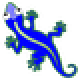

In [40]:
target_label = 'lizard_blue' #@param ["liz_no_tail", "liz_no_leg", "liz_no_head", "lizard_no_arm", "lizard_red", "lizard_blue"]

target_img = load_image_from_file(target_map[target_label])
imshow(zoom(to_rgb(target_img), 2), fmt='png')

## Different starter matrices for CMA-ES

The gradient/backprop approach finds *an* attack matrix, but only an imperfect local optimum. Here we ask how CMA-ES behaves when seeded from three very different starting matrices, all optimised under the **same budget** (500 generations, best Optuna config):

1. **Identity** &mdash; the neutral baseline (the mutation is a no-op at the start).
2. **Gradient-trained matrix** &mdash; start from the matrix backprop already found. *Main experiment:* does CMA-ES keep improving past the gradient optimum, or regress away from it?
3. **Random noise** &mdash; a full random symmetric matrix (entries ~ N(0, 1)); a negative-control / stress test far from any working regime.

**Phase 1** trains the gradient matrix (so we have both its final matrix `M_grad` and its loss curve `grad_loss_log`). **Phase 2** runs the three CMA-ES experiments via a single reusable `run_cmaes(...)`. The final two cells compare the runs quantitatively (loss curves, transition plot, table) and qualitatively (grown images).

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth


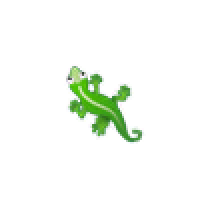

loss0 (empty seed): 0.021845243871212006


In [41]:
#@title Shared setup & helpers (seed, NCA, CMA-ES eval, render, METRICS)
import time
%pip install -q cma lpips
import cma
import lpips

# ---- METRICS: SSIM, LPIPS, Fourier ----
# Boolean flag for Fourier: compute on whole image (False) or on 2x2 parts (True)
fourier_use_parts = False  # Set to True to compute spectral difference on 4 quadrants

def compute_ssim(img1, img2):
    """img1, img2: numpy arrays (H,W,3) in [0,1]"""
    img1_tf = tf.convert_to_tensor(img1[None, ...], dtype=tf.float32)
    img2_tf = tf.convert_to_tensor(img2[None, ...], dtype=tf.float32)
    return float(tf.image.ssim(img1_tf, img2_tf, max_val=1.0).numpy())

# LPIPS: need to move images to [-1,1] and use torch
loss_fn_alex = lpips.LPIPS(net='alex').cuda() if torch.cuda.is_available() else lpips.LPIPS(net='alex')
def compute_lpips(img1, img2):
    # img1, img2: numpy (H,W,3) in [0,1]
    t1 = torch.tensor(img1.transpose(2,0,1)[None, ...], dtype=torch.float32)
    t2 = torch.tensor(img2.transpose(2,0,1)[None, ...], dtype=torch.float32)
    t1 = t1 * 2.0 - 1.0
    t2 = t2 * 2.0 - 1.0
    if torch.cuda.is_available():
        t1, t2 = t1.cuda(), t2.cuda()
    with torch.no_grad():
        d = loss_fn_alex(t1, t2)
    return float(d.item())

def compute_fourier_diff(img1, img2):
    """Return mean absolute difference of log magnitude spectra."""
    # Convert to grayscale (average over RGB) for simplicity
    gray1 = np.mean(img1, axis=-1)
    gray2 = np.mean(img2, axis=-1)
    f1 = np.fft.fft2(gray1)
    f2 = np.fft.fft2(gray2)
    mag1 = np.log1p(np.abs(f1))
    mag2 = np.log1p(np.abs(f2))
    return float(np.mean(np.abs(mag1 - mag2)))

def compute_fourier_diff_parts(img1, img2, n_parts=2):
    """Split image into n_parts x n_parts blocks, compute average spectral diff per block."""
    h, w = img1.shape[:2]
    ph, pw = h // n_parts, w // n_parts
    diffs = []
    for i in range(n_parts):
        for j in range(n_parts):
            block1 = img1[i*ph:(i+1)*ph, j*pw:(j+1)*pw]
            block2 = img2[i*ph:(i+1)*ph, j*pw:(j+1)*pw]
            diffs.append(compute_fourier_diff(block1, block2))
    return float(np.mean(diffs))

def compute_all_metrics(img_target, img_grown):
    ssim_val = compute_ssim(img_target, img_grown)
    lpips_val = compute_lpips(img_target, img_grown)
    if fourier_use_parts:
        fourier_val = compute_fourier_diff_parts(img_target, img_grown, n_parts=2)
    else:
        fourier_val = compute_fourier_diff(img_target, img_grown)
    return ssim_val, lpips_val, fourier_val

# ---- target & seed (shared by the gradient phase and all CMA-ES runs) ----
TARGET_PADDING = 32
p = TARGET_PADDING
pad_target = tf.pad(target_img, [(p, p), (p, p), (0, 0)])
h, w = pad_target.shape[:2]

seed = np.zeros([h, w, CHANNEL_N], np.float32)
seed[h // 2, w // 2, 3:] = 1.0

def loss_f(x):
    return tf.reduce_mean(tf.square(to_rgba(x) - pad_target), [-2, -3, -1])

target_emoji = '🦎'
ca = get_model(emoji=target_emoji)

# Grow a healthy lizard once; used as a second seed source and for the morph demos.
x0_seed = seed[None, ...]
for _ in tf.range(200):
    x0_seed = ca(x0_seed)
imshow(zoom(to_rgb(x0_seed[0]), 2), fmt='png')

loss0 = float(loss_f(seed).numpy())
print('loss0 (empty seed):', loss0)

def fresh_pool():
    elems = np.concatenate([
        np.repeat(seed[None, ...], POOL_SIZE // 2, 0),
        np.repeat(x0_seed,         POOL_SIZE // 2, 0)], 0)
    return SamplePool(x=elems)

# ---- 136-vec <-> symmetric 16x16 conversions ----
_iu16 = np.triu_indices(CHANNEL_N)   # upper triangle incl. diagonal -> 136 entries

def vec_to_sym(vec):
    M = np.zeros((CHANNEL_N, CHANNEL_N), np.float32)
    M[_iu16] = np.asarray(vec, np.float32)
    return M + M.T - np.diag(np.diag(M))

def sym_to_vec(M):
    return np.asarray(M, np.float32)[_iu16].copy()

def var_to_sym(var):
    m_upper = tf.linalg.band_part(var, 0, -1)
    return (m_upper + tf.transpose(m_upper)
            - tf.linalg.tensor_diag(tf.linalg.diag_part(var))).numpy()

# ---- batched CMA-ES candidate evaluation (one fused NCA pass over the population) ----
_indicator = np.zeros((CHANNEL_N, CHANNEL_N, len(_iu16[0])), np.float32)
for _k in range(len(_iu16[0])):
    _r, _c = _iu16[0][_k], _iu16[1][_k]
    _indicator[_r, _c, _k] = 1.0
    _indicator[_c, _r, _k] = 1.0
indicator_tf = tf.constant(_indicator)

@tf.function(jit_compile=True)
def evaluate_batch(x_init, V, iter_n):
    P = V.shape[0]
    B, H, W, C = x_init.shape
    M = tf.einsum('pk,ijk->pij', V, indicator_tf)
    x = tf.tile(x_init[None], [P, 1, 1, 1, 1])
    for _ in tf.range(iter_n):
        x_flat = tf.reshape(x, [P * B, H, W, C])
        lm = tf.cast(get_living_mask(x_flat), tf.float32)
        lm = tf.reshape(lm, [P, B, H, W, 1])
        x = tf.einsum('pbhwc,pcd->pbhwd', x, M)
        x = tf.clip_by_value(x, -3., 3.)
        x = x * lm
        x_flat = tf.reshape(x, [P * B, H, W, C])
        x_flat = ca(x_flat)
        x = tf.reshape(x_flat, [P, B, H, W, C])
    x_flat = tf.reshape(x, [P * B, H, W, C])
    losses = tf.reshape(loss_f(x_flat), [P, B])
    return x, tf.reduce_mean(losses, axis=1)

# ---- growing / evaluating a single matrix for visualisation & final metrics ----
RENDER_STEPS = 120   # NCA steps used to grow an image for display
EVAL_STEPS   = 96    # NCA steps used for the "grown-image loss" metric
EVAL_RUNS    = 4     # stochastic renders averaged for that metric

def render_growth(M, x_start, steps, capture=()):
    M_t = tf.constant(np.asarray(M, np.float32))
    x = tf.constant(np.asarray(x_start, np.float32)[None])
    cap = set(capture)
    frames = []
    for i in range(steps + 1):
        if i in cap:
            frames.append((i, to_rgb(x[0]).numpy()))
        lm = tf.cast(get_living_mask(x), tf.float32)
        x = tf.einsum('bhwc,cd->bhwd', x, M_t)
        x = tf.clip_by_value(x, -3., 3.) * lm
        x = ca(x)
    return x, frames

def grown_image_loss(M, steps=EVAL_STEPS, runs=EVAL_RUNS):
    vals = [float(loss_f(render_growth(M, seed, steps)[0])[0]) for _ in range(runs)]
    return float(np.mean(vals)), float(np.std(vals))

!mkdir -p train_log && rm -f train_log/*

## Phase 0 &mdash; Random Baseline Attack and Metrics

Create a random symmetric matrix (biased towards identity) and apply it to a fully grown healthy lizard for a few steps. Compute SSIM, LPIPS, and Fourier metrics against the original healthy lizard. This same matrix will later be used as the "random" starter in Phase 2.

[codecarbon INFO @ 10:43:34] [setup] RAM Tracking...
[codecarbon INFO @ 10:43:34] [setup] CPU Tracking...
[codecarbon WARNING @ 10:43:34] We saw that you have a Intel(R) Xeon(R) CPU @ 2.00GHz but we don't know it. Please contact us.
[codecarbon WARNING @ 10:43:34] We will use the default power consumption of 4 W per thread for your 2 CPU, so 8W.
[codecarbon WARNING @ 10:43:34] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist, and are readable, at /sys/class/powercap/intel-rapl/subsystem to measure CPU

[codecarbon INFO @ 10:43:34] CPU Model on constant consumption mode: Intel(R) Xeon(R) CPU @ 2.00GHz
[codecarbon WARNING @ 10:43:34] No CPU tracking mode found. Falling back on CPU load mode.
[codecarbon INFO @ 10:43:34] [setup] GPU Tracking...
[codecarbon INFO @ 10:43:34] Tracking Nvidia GPUs via PyNVML
[codecarbon INFO @ 10:43:34] The below tracking methods have been set up:
                RAM Tracking Meth

Random baseline matrix shape: (16, 16)
Lizard after 120 steps of normal growth:


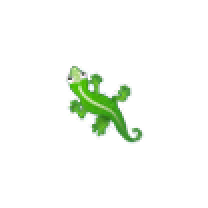

Lizard after 3 steps of random matrix attack:


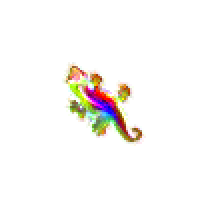

  return float(tf.image.ssim(img1_tf, img2_tf, max_val=1.0).numpy())

[codecarbon INFO @ 10:43:35] Energy consumed for RAM : 0.000003 kWh. RAM Power : 10.0 W



Metrics (healthy vs attacked):
SSIM  : 0.947539
LPIPS : 0.361766
Fourier diff (log-mag): 0.340985


[codecarbon INFO @ 10:43:35] Delta energy consumed for CPU with cpu_load : 0.000000 kWh, power : 0.8000072 W
[codecarbon INFO @ 10:43:35] Energy consumed for All CPU : 0.000000 kWh
[codecarbon INFO @ 10:43:35] Monitoring GPUs with indices: [0] out of 1 total GPUs
[codecarbon INFO @ 10:43:35] Energy consumed for all GPUs : 0.000007 kWh. Total GPU Power : 13.913450703344195 W
[codecarbon INFO @ 10:43:35] 0.000010 kWh of electricity and 0.000000 L of water were used since the beginning.



Phase 0 Emissions: 3.5810368761992662e-06 kg CO2eq


In [ ]:
#@title Phase 0: Random matrix attack and metrics
tracker_p0 = EmissionsTracker(project_name="Phase_0_Random", output_dir=SAVE_DIR, log_level="error")
tracker_p0.start()

np.random.seed(42)
random_mat = np.random.randn(CHANNEL_N, CHANNEL_N).astype(np.float32)
random_mat = (random_mat + random_mat.T) / 2   # symmetric
strength = 0.1
random_mat_baseline = tf.eye(CHANNEL_N) + strength * random_mat   # identity bias

print("Random baseline matrix shape:", random_mat_baseline.shape)

# Grow a healthy lizard from empty seed (same as x0_seed)
x_healthy = seed[None, ...]
for _ in range(RENDER_STEPS):
    x_healthy = ca(x_healthy)
print(f"Lizard after {RENDER_STEPS} steps of normal growth:")
imshow(zoom(to_rgb(x_healthy[0]), 2), fmt='png')

# Apply random attack for a few steps
attack_steps = 3
x_attacked = x_healthy
for step in range(attack_steps):
    lm = tf.cast(get_living_mask(x_attacked), tf.float32)
    x_attacked = x_attacked @ random_mat_baseline
    x_attacked = tf.clip_by_value(x_attacked, -3.0, 3.0) * lm
    x_attacked = ca(x_attacked)

print(f"Lizard after {attack_steps} steps of random matrix attack:")
imshow(zoom(to_rgb(x_attacked[0]), 2), fmt='png')

# Compute metrics
img_healthy = to_rgb(x_healthy[0]).numpy()
img_attacked = to_rgb(x_attacked[0]).numpy()
ssim_val, lpips_val, fourier_val = compute_all_metrics(img_healthy, img_attacked)

print("\nMetrics (healthy vs attacked):")
print(f"SSIM  : {ssim_val:.6f}")
print(f"LPIPS : {lpips_val:.6f}")
print(f"Fourier diff (log-mag): {fourier_val:.6f}")

emissions_p0 = tracker_p0.stop()
print(f"\nPhase 0 Emissions: {emissions_p0} kg CO2eq")

## Phase 1 &mdash; gradient baseline (produces `M_grad` + its loss curve)

Train the symmetric mutation matrix by backprop, exactly as in the original gradient approach. We keep both the final matrix (`M_grad`) and the full per-step loss history (`grad_loss_log`): the matrix seeds CMA-ES run 2, and the loss history is the left half of the transition plot later.

> This runs the full backprop training (8000 steps) and is the slow part of the notebook.

batch (before/after):


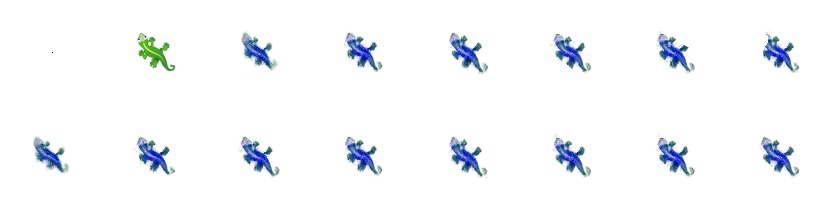

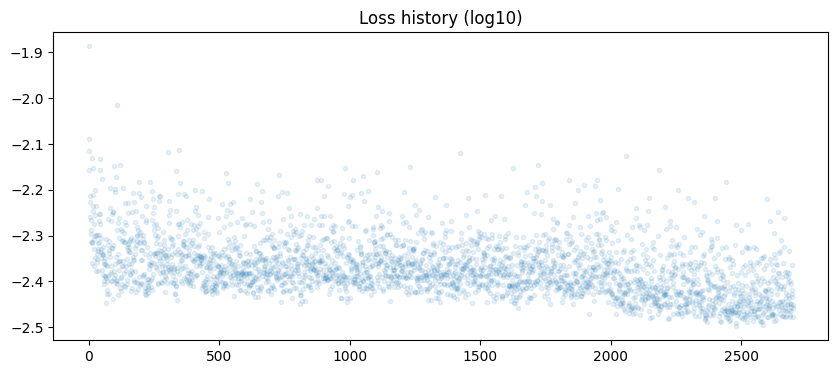

 step: 2701, log10(loss): -2.457

[codecarbon INFO @ 11:00:22] Delta energy consumed for CPU with cpu_load : 0.000013 kWh, power : 3.3208704318500004 W
[codecarbon INFO @ 11:00:22] Energy consumed for All CPU : 0.000935 kWh
[codecarbon INFO @ 11:00:22] Energy consumed for all GPUs : 0.018252 kWh. Total GPU Power : 65.12416055215775 W
[codecarbon INFO @ 11:00:22] 0.021886 kWh of electricity and 0.000000 L of water were used since the beginning.


 step: 2732, log10(loss): -2.451

[codecarbon INFO @ 11:00:34] Energy consumed for RAM : 0.005356 kWh. RAM Power : 10.0 W


 step: 2734, log10(loss): -2.374

...

 step: 2746, log10(loss): -2.416

[codecarbon INFO @ 11:00:39] Energy consumed for RAM : 0.002745 kWh. RAM Power : 10.0 W


 step: 2747, log10(loss): -2.501
Early stopping triggered at step 2746. Target loss reached: 0.00315

Gradient phase done. best log10(loss): -2.501


[codecarbon INFO @ 11:00:40] Delta energy consumed for CPU with cpu_load : 0.000003 kWh, power : 4.860092600000001 W
[codecarbon INFO @ 11:00:40] Energy consumed for All CPU : 0.000950 kWh
[codecarbon INFO @ 11:00:40] Energy consumed for all GPUs : 0.018568 kWh. Total GPU Power : 61.0406482804679 W
[codecarbon INFO @ 11:00:40] 0.022263 kWh of electricity and 0.000000 L of water were used since the beginning.



Phase 1 Emissions: 0.007774954631871275 kg CO2eq


In [ ]:
#@title Phase 1: gradient training loop {vertical-output: true}
tracker_p1 = EmissionsTracker(project_name="Phase_1_Gradient", output_dir=SAVE_DIR, log_level="error")
tracker_p1.start()

grad_mut_path = os.path.join(SAVE_DIR, 'M_grad.npy')
loss_log_path = os.path.join(SAVE_DIR, 'grad_loss_log.npy')

grad_mut = tf.Variable(tf.eye(CHANNEL_N))
grad_loss_log = []

if os.path.exists(grad_mut_path) and os.path.exists(loss_log_path):
    print(f"Loading existing Phase 1 model from {SAVE_DIR}")
    M_grad = np.load(grad_mut_path)
    grad_loss_log = np.load(loss_log_path).tolist()
    grad_mut.assign(M_grad)
else:
    grad_lr = 2e-3
    grad_sched = tf.keras.optimizers.schedules.PiecewiseConstantDecay(
        [2000], [grad_lr, grad_lr * 0.1])
    grad_trainer = tf.keras.optimizers.Adam(grad_sched)
    grad_pool = fresh_pool()

    @tf.function
    def grad_train_step(x):
        iter_n = tf.random.uniform([], 64, 96, tf.int32)
        with tf.GradientTape() as g:
            m_upper = tf.linalg.band_part(grad_mut, 0, -1)
            M = (m_upper + tf.transpose(m_upper)
                 - tf.linalg.tensor_diag(tf.linalg.diag_part(grad_mut)))
            for _ in tf.range(iter_n):
                lm = tf.cast(get_living_mask(x), tf.float32)
                x = tf.einsum('bhwc,cd->bhwd', x, M)
                x = tf.clip_by_value(x, -3., 3.) * lm
                x = ca(x)
            loss = tf.reduce_mean(loss_f(x))
        grads = g.gradient(loss, [grad_mut])
        grads = [gr / (tf.norm(gr) + 1e-8) for gr in grads]
        grad_trainer.apply_gradients(zip(grads, [grad_mut]))
        return x, loss

    for i in range(8000 + 1):
        batch = grad_pool.sample(BATCH_SIZE)
        x0 = batch.x
        x0 = x0[loss_f(x0).numpy().argsort()[::-1]]
        x0[:1] = seed
        x0[1:2] = x0_seed[0]
        if DAMAGE_N:
            damage = 1.0 - make_circle_masks(DAMAGE_N, h, w).numpy()[..., None]
            x0[-DAMAGE_N:] *= damage

        x, loss = grad_train_step(x0)
        batch.x[:] = x
        batch.commit()

        step_i = len(grad_loss_log)
        grad_loss_log.append(float(loss))
        if step_i % 100 == 0:
            clear_output()
            visualize_batch(x0, x, step_i)
            plot_loss(grad_loss_log)
        print('\r step: %d, log10(loss): %.3f' % (len(grad_loss_log), np.log10(loss)), end='')

        if np.log10(loss) <= LOSS_THRESHOLD:
             print(f"\nEarly stopping triggered at step {i}. Target loss reached: {float(loss):.5f}")
             break

    M_grad = var_to_sym(grad_mut)
    np.save(grad_mut_path, M_grad)
    np.save(loss_log_path, np.array(grad_loss_log))
    print('\nGradient phase done. best log10(loss): %.3f' % np.log10(min(grad_loss_log)))

emissions_p1 = tracker_p1.stop()
print(f"\nPhase 1 Emissions: {emissions_p1} kg CO2eq")

## Phase 2 &mdash; CMA-ES from three starting matrices

`run_cmaes(init_vec, label, ...)` runs one CMA-ES optimisation from a given 136-vector starting mean and returns its loss history, best loss, best vector, and the recovered symmetric matrix. We call it once per starter, all with the same budget and config (and the same RNG seed) so the only difference between runs is the starting matrix.

In [ ]:
#@title run_cmaes() + the three starter matrices {vertical-output: true}

# === Best trial from the Optuna hyperparameter search ===
#   loss=0.004239  {'sigma0': 0.004789, 'batch_size': 4, 'popsize': 64,
#                   'decay_factor': 0.9, 'decay_freq': 175}
N_GENERATIONS = 600
CMA_BATCH     = 4
CMA_POPSIZE   = 64
SIGMA0        = 0.004789
DECAY_FACTOR  = 0.9
DECAY_FREQ    = 175

def run_cmaes(init_vec, label, n_generations=N_GENERATIONS, seed_rng=0):
    tracker_p2 = EmissionsTracker(project_name=f"Phase_2_{label}", output_dir=SAVE_DIR, log_level="error")
    tracker_p2.start()

    # File paths for checkpointing based on label
    m_path = os.path.join(SAVE_DIR, f'M_cmaes_{label}.npy')
    loss_log_path = os.path.join(SAVE_DIR, f'loss_log_cmaes_{label}.npy')
    best_loss_path = os.path.join(SAVE_DIR, f'best_loss_cmaes_{label}.npy')
    best_vec_path = os.path.join(SAVE_DIR, f'best_vec_cmaes_{label}.npy')
    time_log_path = os.path.join(SAVE_DIR, f'time_log_cmaes_{label}.npy')

    # Check if already trained
    if os.path.exists(m_path) and os.path.exists(loss_log_path):
        print(f"Loading existing CMA-ES results for [{label}] from {SAVE_DIR}")
        M_cmaes = np.load(m_path)
        loss_log = np.load(loss_log_path).tolist()
        best_loss = float(np.load(best_loss_path))
        best_vec = np.load(best_vec_path)
        time_log = np.load(time_log_path).tolist()
        
        emissions_p2 = tracker_p2.stop()
        print(f"[{label}] Emissions (just loading): {emissions_p2} kg CO2eq")
        
        return dict(label=label, loss_log=loss_log, time_log=time_log,
                    best_loss=best_loss, best_vec=best_vec, M=M_cmaes, emissions=emissions_p2)

    init_vec = np.asarray(init_vec, np.float32)
    np.random.seed(seed_rng)
    es = cma.CMAEvolutionStrategy(
        init_vec, SIGMA0, {'popsize': CMA_POPSIZE, 'verbose': -9})
    pool = fresh_pool()

    evaluate_batch(tf.constant(pool.sample(CMA_BATCH).x),
                   tf.constant(np.zeros((CMA_POPSIZE, len(init_vec)), np.float32)),
                   tf.constant(80, tf.int32))

    loss_log, time_log = [], []
    best_loss, best_vec = np.inf, None
    start = time.time()
    for gen in range(n_generations):
        if gen > 0 and gen % DECAY_FREQ == 0:
            es.sigma *= DECAY_FACTOR
        iter_n = np.random.randint(64, 96)
        batch = pool.sample(CMA_BATCH)
        x0 = batch.x
        x0 = x0[loss_f(x0).numpy().argsort()[::-1]]
        x0[:1] = seed
        x0[1:2] = x0_seed[0]
        if DAMAGE_N:
            dmg = 1.0 - make_circle_masks(DAMAGE_N, h, w).numpy()[..., None]
            x0[-DAMAGE_N:] *= dmg

        cands = es.ask()
        V = tf.constant(np.stack(cands).astype(np.float32))
        xs, fit_t = evaluate_batch(tf.constant(x0), V, tf.constant(iter_n, tf.int32))
        fit = fit_t.numpy().tolist()
        es.tell(cands, fit)

        elite = int(np.argmin(fit))
        batch.x[:] = xs[elite].numpy(); batch.commit()
        if min(fit) < best_loss:
            best_loss = min(fit); best_vec = np.array(cands[elite], np.float32)

        loss_log.append(min(fit))
        time_log.append(time.time() - start)
        print(f"\r[{label}] gen {gen + 1:4d}/{n_generations}  "
              f"log10(loss)={np.log10(min(fit)):.3f}  best={np.log10(best_loss):.3f}  "
              f"sigma={es.sigma:.2e}", end='')

        if np.log10(best_loss) <= LOSS_THRESHOLD:
            print(f"\n[{label}] Early stopping triggered at generation {gen + 1}. Target loss ({loss_threshold}) reached: {best_loss:.5f}")
            break
    
    M_cmaes = vec_to_sym(best_vec)

    # Save results to prevent evolving again
    np.save(m_path, M_cmaes)
    np.save(loss_log_path, np.array(loss_log))
    np.save(best_loss_path, np.array(best_loss))
    np.save(best_vec_path, best_vec)
    np.save(time_log_path, np.array(time_log))

    print(f"\n[{label}] done: best log10(loss)={np.log10(best_loss):.3f}")
    emissions_p2 = tracker_p2.stop()
    print(f"[{label}] Emissions: {emissions_p2} kg CO2eq")
    
    return dict(label=label, loss_log=loss_log, time_log=time_log,
                best_loss=best_loss, best_vec=best_vec, M=M_cmaes, emissions=emissions_p2)

# ---- the three starting matrices (as 136-vectors) ----
init_identity = sym_to_vec(np.eye(CHANNEL_N, dtype=np.float32))

init_grad = sym_to_vec(M_grad)                 # the gradient-trained matrix from Phase 1

# Use the same random matrix from Phase 0 as the "random" starter (coherent)
init_random = sym_to_vec(random_mat_baseline.numpy())

print('starter vectors ready:',
      'identity', init_identity.shape,
      '| gradient', init_grad.shape,
      '| random', init_random.shape)

starter vectors ready: identity (136,) | gradient (136,) | random (136,)


In [ ]:
#@title Run 1 / 3 - CMA-ES from identity {vertical-output: true}
res_identity = run_cmaes(init_identity, 'identity')

[codecarbon WARNING @ 11:00:40] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 11:00:40] [setup] RAM Tracking...
[codecarbon INFO @ 11:00:40] [setup] CPU Tracking...
[codecarbon WARNING @ 11:00:40] We saw that you have a Intel(R) Xeon(R) CPU @ 2.00GHz but we don't know it. Please contact us.
[codecarbon WARNING @ 11:00:40] We will use the default power consumption of 4 W per thread for your 2 CPU, so 8W.
[codecarbon WARNING @ 11:00:40] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist, and are readable, at /sys/class/powercap/intel-rapl/subsystem to measure CPU

[codecarbon INFO @ 11:00:40] CPU Model on constant consumption mode: Intel(R) Xeon(R) CPU @ 2.00GHz
[codecarbon WARNING @ 11:00:40] No CPU tracking mode found. Falling back on CPU load mode.
[codecarbon INFO @ 11:00:40] [setup] GPU Tracking...
[codecarbon INFO @ 11:00:40] Tracking Nvidia GPUs via PyNVML
[code

[identity] gen    1/600  log10(loss)=-2.071  best=-2.071  sigma=4.55e-03

[codecarbon INFO @ 11:01:04] Energy consumed for RAM : 0.005437 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 11:01:05] Delta energy consumed for CPU with cpu_load : 0.000018 kWh, power : 4.4628205106461545 W
[codecarbon INFO @ 11:01:05] Energy consumed for All CPU : 0.001379 kWh
[codecarbon INFO @ 11:01:05] Energy consumed for all GPUs : 0.029934 kWh. Total GPU Power : 62.57458236557546 W
[codecarbon INFO @ 11:01:05] 0.036749 kWh of electricity and 0.000000 L of water were used since the beginning.


[identity] gen    3/600  log10(loss)=-2.178  best=-2.178  sigma=4.41e-03

[codecarbon INFO @ 11:01:12] Energy consumed for RAM : 0.000086 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 11:01:12] Delta energy consumed for CPU with cpu_load : 0.000013 kWh, power : 3.20675377328 W
[codecarbon INFO @ 11:01:12] Energy consumed for All CPU : 0.000028 kWh
[codecarbon INFO @ 11:01:13] Energy consumed for all GPUs : 0.000529 kWh. Total GPU Power : 60.74657967657265 W
[codecarbon INFO @ 11:01:13] 0.000643 kWh of electricity and 0.000000 L of water were used since the beginning.


...

[identity] gen  580/600  log10(loss)=-2.310  best=-2.405  sigma=6.73e-04

[codecarbon INFO @ 11:32:49] Energy consumed for RAM : 0.010545 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 11:32:50] Delta energy consumed for CPU with cpu_load : 0.000013 kWh, power : 3.3150439412 W
[codecarbon INFO @ 11:32:50] Energy consumed for All CPU : 0.003136 kWh
[codecarbon INFO @ 11:32:50] Energy consumed for all GPUs : 0.063882 kWh. Total GPU Power : 64.35402223410043 W
[codecarbon INFO @ 11:32:50] 0.077564 kWh of electricity and 0.000000 L of water were used since the beginning.


[identity] gen  582/600  log10(loss)=-2.342  best=-2.405  sigma=6.70e-04

[codecarbon INFO @ 11:32:57] Energy consumed for RAM : 0.005195 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 11:32:58] Delta energy consumed for CPU with cpu_load : 0.000013 kWh, power : 3.1284849401000003 W
[codecarbon INFO @ 11:32:58] Energy consumed for All CPU : 0.001789 kWh
[codecarbon INFO @ 11:32:58] Energy consumed for all GPUs : 0.034494 kWh. Total GPU Power : 64.76233324141288 W
[codecarbon INFO @ 11:32:58] 0.041478 kWh of electricity and 0.000000 L of water were used since the beginning.


[identity] gen  584/600  log10(loss)=-2.357  best=-2.405  sigma=6.70e-04

In [ ]:
#@title Run 2 / 3 - CMA-ES from the gradient matrix (main experiment) {vertical-output: true}
res_grad = run_cmaes(init_grad, 'gradient-start')

In [ ]:
#@title Run 3 / 3 - CMA-ES from random baseline matrix {vertical-output: true}
res_random = run_cmaes(init_random, 'random')

## Results & comparison

Quantitative (loss curves, the gradient&rarr;CMA-ES transition plot, a summary table and final-loss bars) followed by qualitative grown-image comparisons. Additionally, compute and display SSIM, LPIPS, Fourier metrics for each final grown image against the target.

In [ ]:
#@title Quantitative comparison {vertical-output: true}
runs = [res_identity, res_grad, res_random]
colors = {'identity': 'tab:blue', 'gradient-start': 'tab:green', 'random': 'tab:red'}

# grown-from-seed loss is the metric that actually matters; compute each matrix once
grown = {r['label']: grown_image_loss(r['M']) for r in runs}
grown['gradient'] = grown_image_loss(M_grad)

# ---- (a) overlay of the three CMA-ES loss curves ----
pl.figure(figsize=(9, 4))
for r in runs:
    pl.plot(np.log10(r['loss_log']), '.', alpha=.3, label=r['label'],
            color=colors[r['label']])
pl.axhline(np.log10(loss0), ls='--', c='gray', label='empty-seed baseline')
pl.title('CMA-ES loss by starter matrix'); pl.xlabel('generation')
pl.ylabel('log10(loss)'); pl.legend(); pl.tight_layout(); pl.show()

# ---- (b) main experiment: gradient -> CMA-ES, with the transition marked ----
grad_best = min(grad_loss_log)
n_grad, n_cma = len(grad_loss_log), len(res_grad['loss_log'])
pl.figure(figsize=(11, 4))
pl.plot(range(n_grad), np.log10(grad_loss_log), '.', alpha=.25,
        color='tab:purple', label='Phase 1: gradient (per step)')
pl.plot(range(n_grad, n_grad + n_cma), np.log10(res_grad['loss_log']), '.',
        alpha=.5, color='tab:green', label='Phase 2: CMA-ES (per generation)')
pl.axvline(n_grad, ls='--', c='k', lw=1)
pl.text(n_grad, pl.ylim()[1], '  CMA-ES takes over', va='top', fontsize=9)
pl.axhline(np.log10(grad_best), ls=':', c='tab:purple',
           label=f'gradient best training loss ({grad_best:.5f})')
grad_grown, cma_grown = grown['gradient'][0], grown['gradient-start'][0]
verdict = 'IMPROVED on' if cma_grown < grad_grown else 'REGRESSED from'
pl.title(f"Main experiment: CMA-ES {verdict} the gradient optimum  "
         f"(grown-image loss {grad_grown:.5f} -> {cma_grown:.5f})")
pl.xlabel('training progress  (gradient steps | CMA-ES generations)')
pl.ylabel('log10(loss)'); pl.legend(); pl.tight_layout(); pl.show()

# ---- (c) summary table incl. grown-from-seed loss ----
print('=' * 80)
print(f"{'starter':16s}{'best loss':>14s}{'final loss':>14s}"
      f"{'grown loss':>14s}{'grown std':>12s}{'wall s':>10s}")
print('-' * 80)
for r in runs:
    gm, gs = grown[r['label']]
    print(f"{r['label']:16s}{r['best_loss']:>14.6f}{r['loss_log'][-1]:>14.6f}"
          f"{gm:>14.6f}{gs:>12.6f}{r['time_log'][-1]:>10.0f}")
gm, gs = grown['gradient']
print(f"{'gradient (P1)':16s}{grad_best:>14.6f}{grad_loss_log[-1]:>14.6f}"
      f"{gm:>14.6f}{gs:>12.6f}{'-':>10s}")
print('-' * 80)
print(f"{'empty-seed loss0':16s}{loss0:>14.6f}")
print('=' * 80)

# ---- (d) final-loss bar chart ----
labels    = [r['label'] for r in runs] + ['gradient']
best_vals = [r['best_loss'] for r in runs] + [grad_best]
grown_m   = [grown[l][0] for l in labels]
grown_s   = [grown[l][1] for l in labels]
xpos = np.arange(len(labels)); bw = 0.38
pl.figure(figsize=(9, 4))
pl.bar(xpos - bw / 2, best_vals, bw, label='best training loss')
pl.bar(xpos + bw / 2, grown_m, bw, yerr=grown_s, capsize=4, label='grown-image loss')
pl.axhline(loss0, ls='--', c='gray', label='empty-seed baseline')
pl.xticks(xpos, labels); pl.ylabel('loss'); pl.title('Final loss by starter matrix')
pl.legend(); pl.tight_layout(); pl.show()

# ---- (e) additional metrics: SSIM, LPIPS, Fourier ----
print("\n===== ADDITIONAL METRICS (against target image) =====")
target_np = to_rgb(pad_target).numpy()
print(f"{'starter':16s} {'SSIM':>8s} {'LPIPS':>8s} {'Fourier diff':>12s}")
for r in runs:
    grown_img = to_rgb(render_growth(r['M'], seed, RENDER_STEPS)[0][0]).numpy()
    ssim_val, lpips_val, fourier_val = compute_all_metrics(target_np, grown_img)
    print(f"{r['label']:16s} {ssim_val:8.6f} {lpips_val:8.6f} {fourier_val:12.6f}")
grown_img_grad = to_rgb(render_growth(M_grad, seed, RENDER_STEPS)[0][0]).numpy()
ssim_val, lpips_val, fourier_val = compute_all_metrics(target_np, grown_img_grad)
print(f"{'gradient (P1)':16s} {ssim_val:8.6f} {lpips_val:8.6f} {fourier_val:12.6f}")

In [ ]:
#@title Qualitative comparison: grown images {vertical-output: true}
runs = [res_identity, res_grad, res_random]
CAP = [0, 20, 40, 60, 80, 100, RENDER_STEPS]

finals = {}
for r in runs:
    fx, frames = render_growth(r['M'], seed, RENDER_STEPS, CAP)
    finals[r['label']] = (fx, frames)
grad_fx, grad_frames = render_growth(M_grad, seed, RENDER_STEPS, CAP)

# ---- target | identity | gradient-start | random (grown from the empty seed) ----
trio = np.hstack([
    to_rgb(pad_target).numpy(),
    to_rgb(finals['identity'][0][0]).numpy(),
    to_rgb(finals['gradient-start'][0][0]).numpy(),
    to_rgb(finals['random'][0][0]).numpy(),
])
print('Target | identity | gradient-start | random   (grown from the empty seed)')
imshow(zoom(trio, 2), fmt='png')

# ---- growth strips per run ----
strips = [('gradient (Phase 1)', grad_frames)] + \
         [(r['label'], finals[r['label']][1]) for r in runs]
for name, frames in strips:
    print(f'{name} growth (steps {CAP}):')
    imshow(zoom(np.hstack([f for _, f in frames]), 2), fmt='png')

# ---- mutation applied to an already-grown (healthy) lizard ----
morphs = [to_rgb(x0_seed[0]).numpy(),
          to_rgb(render_growth(M_grad, x0_seed[0], RENDER_STEPS)[0][0]).numpy()]
for r in runs:
    morphs.append(to_rgb(render_growth(r['M'], x0_seed[0], RENDER_STEPS)[0][0]).numpy())
print('Healthy | gradient | identity | gradient-start | random   '
      '(mutation applied to a grown lizard)')
imshow(zoom(np.hstack(morphs), 2), fmt='png')